🚕 BLIND TEST: Loading and preprocessing new taxi data...
Selected 10 files for blind testing:
  1. 20241222.csv.out
  2. 20241214.csv.out
  3. 20241204.csv.out
  4. 20241205.csv.out
  5. 20241215.csv.out
  6. 20241223.csv.out
  7. 20241228.csv.out
  8. 20241217.csv.out
  9. 20241207.csv.out
  10. 20241231.csv.out

📂 Loading CSV files...
Processing: 20241222.csv.out
  ✓ Loaded 1,943,972 records
Processing: 20241214.csv.out
  ✓ Loaded 1,930,164 records
Processing: 20241204.csv.out
  ✓ Loaded 1,894,453 records
Processing: 20241205.csv.out
  ✓ Loaded 1,897,138 records
Processing: 20241215.csv.out
  ✓ Loaded 1,932,348 records
Processing: 20241223.csv.out
  ✓ Loaded 1,935,268 records
Processing: 20241228.csv.out
  ✓ Loaded 1,962,795 records
Processing: 20241217.csv.out
  ✓ Loaded 1,919,061 records
Processing: 20241207.csv.out
  ✓ Loaded 1,893,283 records
Processing: 20241231.csv.out
  ✓ Loaded 1,891,453 records

📊 Combined dataset: 19,199,935 total records

🧹 Data cleaning and filtering...
A

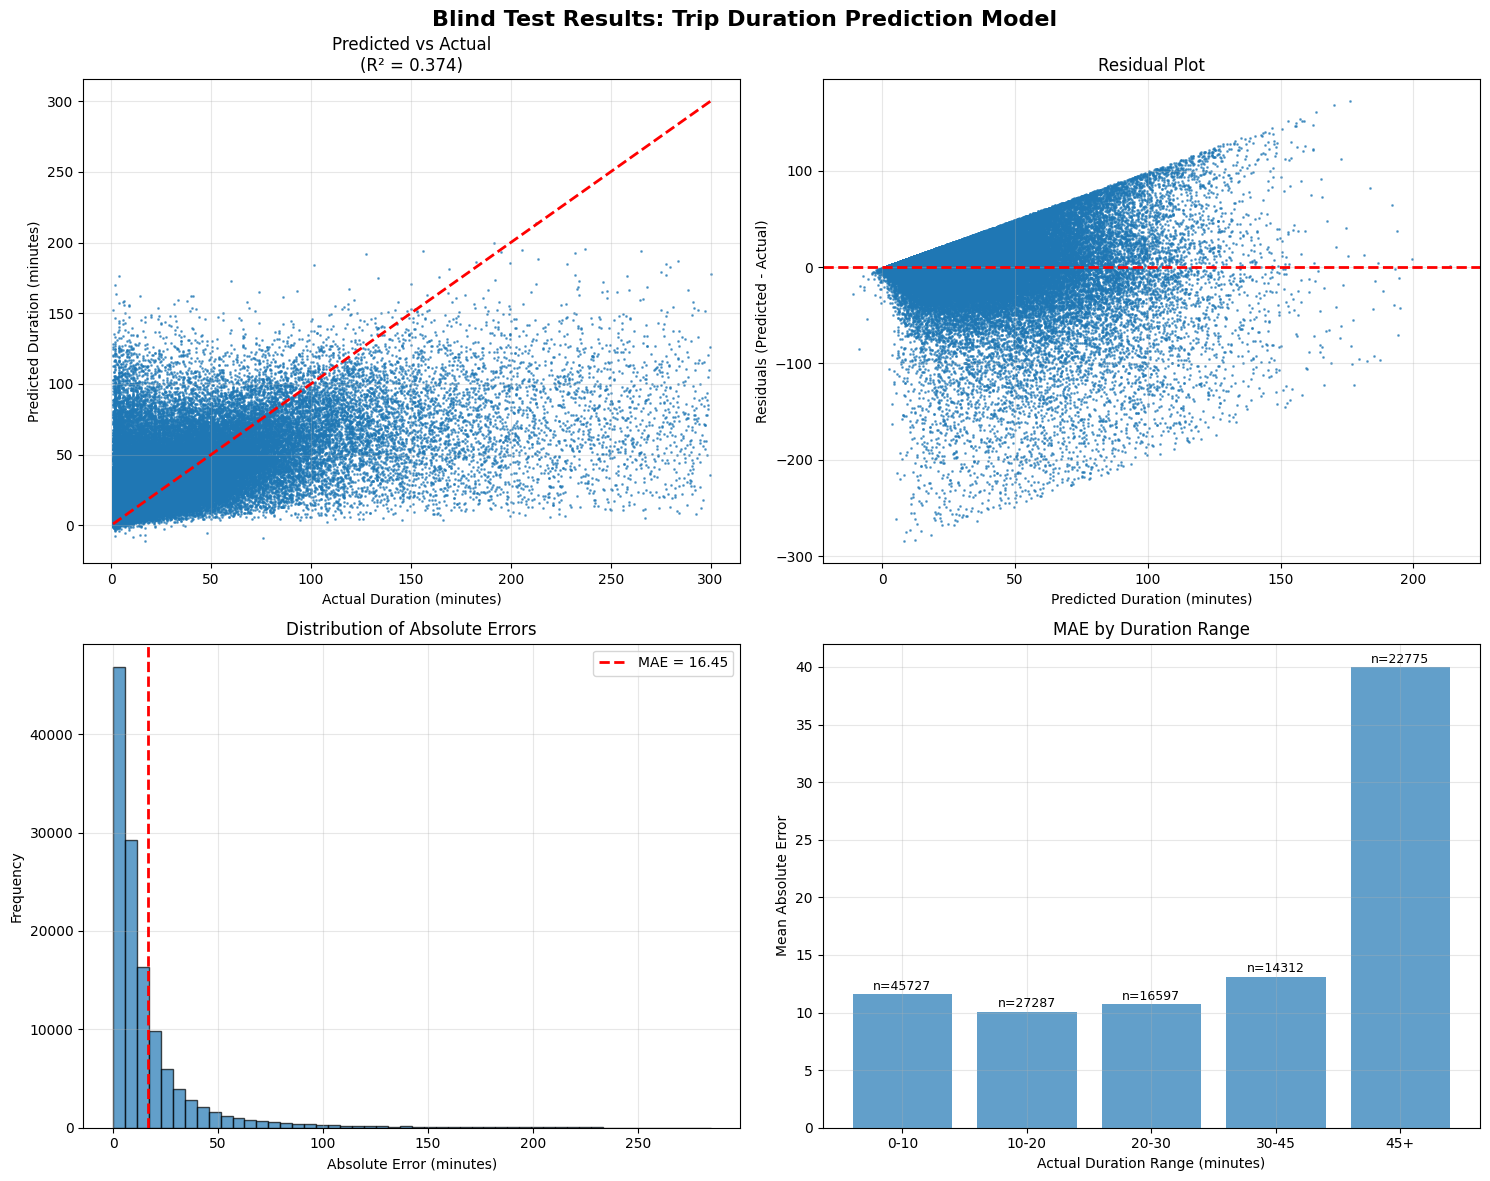


📄 BLIND TEST SUMMARY REPORT
Test Date: 2025-09-25 21:00:12
Data Source: /Users/jul/Desktop/uni/Data Analytics/PROBE-202412
Files Processed: 10
Model: duration_model.joblib

Dataset Statistics:
  • Total trips analyzed: 126,698
  • Unique vehicles: 1451
  • Average trip duration: 28.7 minutes
  • Average trip distance: 19.4 km

Model Performance:
  • Mean Absolute Error: 16.45 minutes
  • Root Mean Square Error: 30.02 minutes
  • R² Score: 0.374
  • Predictions within 10 minutes: 55.6%

Model Status: ⚠️ NEEDS IMPROVEMENT

💾 Detailed results saved to: blind_test_results_duration.csv

🎉 Blind test completed successfully!


In [1]:
# %%
import pandas as pd
import numpy as np
import os
import h3
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# %%
# BLIND TEST CONFIGURATION
BLIND_TEST_FOLDER = '/Users/jul/Desktop/uni/Data Analytics/PROBE-202412'
NUM_FILES_TO_TEST = 10  # Number of .csv.out files to use for blind testing
MODEL_PATH = 'duration_model.joblib'  # Path to your saved model

# Column definitions (same as training)
columns = [
    'VehicleID',
    'gpsvalid',
    'lat',
    'lon',
    'timestamp',
    'speed',
    'heading',
    'for_hire_light',
    'engine_acc'
]

# Bangkok region bounds (same as training)
BKK_REGION_BOUNDS = {
    'min_lat': 13.4,
    'max_lat': 14.2,
    'min_lon': 99.9,
    'max_lon': 101.3
}

# %%
def haversine_distance(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance in kilometers between two points
    on the earth (specified in decimal degrees).
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371 # Radius of earth in kilometers
    return c * r

def calculate_total_trip_fees(distance_km):
    """
    Calculates the taxi fare in THB based on the provided distance in kilometers,
    using the official Thai taxi rate structure.
    """
    if distance_km <= 0:
        return 0

    fare = 35.0  # First 1 km

    if distance_km > 1:
        d = min(distance_km, 10) - 1
        fare += d * 6.50

    if distance_km > 10:
        d = min(distance_km, 20) - 10
        fare += d * 7.00

    if distance_km > 20:
        d = min(distance_km, 40) - 20
        fare += d * 8.00

    if distance_km > 40:
        d = min(distance_km, 60) - 40
        fare += d * 8.50

    if distance_km > 60:
        d = min(distance_km, 80) - 60
        fare += d * 9.00

    if distance_km > 80:
        d = distance_km - 80
        fare += d * 10.50

    return fare

# %%
print("🚕 BLIND TEST: Loading and preprocessing new taxi data...")
print("="*60)

# Get list of .csv.out files
csv_files = [f for f in os.listdir(BLIND_TEST_FOLDER) if f.endswith('.csv.out')]

if len(csv_files) < NUM_FILES_TO_TEST:
    print(f"Warning: Only {len(csv_files)} files found, using all available files")
    NUM_FILES_TO_TEST = len(csv_files)

# Select the first N files for testing
selected_files = csv_files[:NUM_FILES_TO_TEST]
print(f"Selected {len(selected_files)} files for blind testing:")
for i, file in enumerate(selected_files, 1):
    print(f"  {i}. {file}")

# %%
# Load and combine the selected files
print("\n📂 Loading CSV files...")
all_dfs = []

for filename in selected_files:
    file_path = os.path.join(BLIND_TEST_FOLDER, filename)
    print(f"Processing: {filename}")
    
    try:
        df = pd.read_csv(file_path, names=columns)
        all_dfs.append(df)
        print(f"  ✓ Loaded {len(df):,} records")
    except Exception as e:
        print(f"  ❌ Error loading {filename}: {e}")

# Combine all dataframes
combined_df = pd.concat(all_dfs, ignore_index=True)
print(f"\n📊 Combined dataset: {len(combined_df):,} total records")

# %%
print("\n🧹 Data cleaning and filtering...")

# Step 1: Drop NaN values
cleaned_df = combined_df.dropna()
print(f"After dropping NaN: {len(cleaned_df):,} records")

# Step 2: Filter valid GPS and engine data
cleaned_taxi_df = cleaned_df[
    (cleaned_df['gpsvalid'] == 1) &
    (cleaned_df['engine_acc'] == 1) &
    (cleaned_df['lat'].between(-90, 90)) &
    (cleaned_df['lon'].between(-180, 180)) &
    (cleaned_df['speed'] >= 0)
].copy().reset_index(drop=True)
print(f"After GPS/engine filtering: {len(cleaned_taxi_df):,} records")

# Step 3: Identify taxis (vehicles that ever had for_hire_light = 1)
taxi_ids = cleaned_taxi_df[cleaned_taxi_df['for_hire_light'] == 1]['VehicleID'].unique()
taxis_df = cleaned_taxi_df[cleaned_taxi_df['VehicleID'].isin(taxi_ids)].copy()
print(f"After taxi identification: {len(taxis_df):,} records from {len(taxi_ids)} taxis")

# %%
# Step 4: Convert timestamp and sort
taxis_df['timestamp'] = pd.to_datetime(taxis_df['timestamp'])
taxis_df.sort_values(by=['VehicleID', 'timestamp'], inplace=True)
taxis_df.reset_index(drop=True, inplace=True)

# Step 5: Extract time features
taxis_df['hour'] = taxis_df['timestamp'].dt.hour
taxis_df['day_of_week'] = taxis_df['timestamp'].dt.dayofweek
taxis_df['is_weekend'] = (taxis_df['day_of_week'] >= 5).astype(int)

# Step 6: Filter to 2024 only
year_series = taxis_df['timestamp'].dt.year
taxis_df = taxis_df[(year_series == 2024)].copy()
print(f"After 2024 filter: {len(taxis_df):,} records")

# Step 7: Filter to Bangkok region
taxis_df_bkk = taxis_df[
    (taxis_df['lat'] >= BKK_REGION_BOUNDS['min_lat']) &
    (taxis_df['lat'] <= BKK_REGION_BOUNDS['max_lat']) &
    (taxis_df['lon'] >= BKK_REGION_BOUNDS['min_lon']) &
    (taxis_df['lon'] <= BKK_REGION_BOUNDS['max_lon'])
].copy()
print(f"After Bangkok region filter: {len(taxis_df_bkk):,} records")

# Step 8: Filter speed
taxis_df_bkk = taxis_df_bkk[taxis_df_bkk['speed'] <= 180].copy()
print(f"After speed filter: {len(taxis_df_bkk):,} records")

# %%
print("\n🚖 Trip identification and feature engineering...")

# Identify trip starts (for_hire_light changes from 1 to 0)
taxis_df_bkk['trip_start'] = (taxis_df_bkk['for_hire_light'].shift(1) == 1) & (taxis_df_bkk['for_hire_light'] == 0)
taxis_df_bkk['trip_start'] = taxis_df_bkk['trip_start'] & (taxis_df_bkk['VehicleID'].shift(1) == taxis_df_bkk['VehicleID'])
taxis_df_bkk['trip_id'] = taxis_df_bkk.groupby('VehicleID')['trip_start'].cumsum()
taxis_df_bkk.drop(columns=['trip_start'], inplace=True)

# Calculate distances
df = taxis_df_bkk.copy()
df['lat_next'] = df.groupby(['VehicleID', 'trip_id'])['lat'].shift(-1)
df['lon_next'] = df.groupby(['VehicleID', 'trip_id'])['lon'].shift(-1)
df['segment_distance_km'] = haversine_distance(df['lon'], df['lat'], df['lon_next'], df['lat_next'])

# Calculate total trip distances
trip_distances = df.groupby(['VehicleID', 'trip_id'])['segment_distance_km'].sum().reset_index()
trip_distances.rename(columns={'segment_distance_km': 'total_trip_distance_km'}, inplace=True)
df = pd.merge(df, trip_distances, on=['VehicleID', 'trip_id'], how='left')

# Filter unrealistic trips
df = df[df['total_trip_distance_km'] <= 300]  # Max 300km
df = df[df['total_trip_distance_km'] > 0]     # Min distance > 0
print(f"After trip distance filtering: {len(df):,} records")

# Calculate trip fees
df['total_trip_fees'] = df['total_trip_distance_km'].apply(calculate_total_trip_fees)

# %%
# Calculate trip durations
occupied_df = df[df['for_hire_light'] == 0].copy()
trip_durations = occupied_df.groupby(['VehicleID', 'trip_id']).agg({
    'timestamp': ['min', 'max']
}).reset_index()
trip_durations.columns = ['VehicleID', 'trip_id', 'start_time', 'end_time']
trip_durations['duration_minutes'] = (trip_durations['end_time'] - trip_durations['start_time']).dt.total_seconds() / 60

# Merge back to main df
df = pd.merge(df, trip_durations[['VehicleID', 'trip_id', 'duration_minutes']], on=['VehicleID', 'trip_id'], how='left')
df = df.dropna()
print(f"After adding trip durations: {len(df):,} records")

# Filter realistic durations
df = df[df['duration_minutes'].between(1, 300)]  # 1 min to 5 hours
print(f"After duration filtering: {len(df):,} records")

# %%
# Create trip-level features
trip_groups = df.groupby(['VehicleID', 'trip_id'])
df['pickup_hour'] = trip_groups['hour'].transform('first')
df['pickup_dayofweek'] = trip_groups['day_of_week'].transform('first')
df['average_speed'] = trip_groups['speed'].transform('mean')
df['start_lat'] = trip_groups['lat'].transform('first')
df['start_lon'] = trip_groups['lon'].transform('first')
df['end_lat'] = trip_groups['lat'].transform('last')
df['end_lon'] = trip_groups['lon'].transform('last')

# H3 zones and advanced features
df['start_h3_zone'] = df.apply(lambda row: h3.latlng_to_cell(row['start_lat'], row['start_lon'], 7), axis=1)
df['end_h3_zone'] = df.apply(lambda row: h3.latlng_to_cell(row['end_lat'], row['end_lon'], 7), axis=1)
df["is_rush_hour"] = ((df["pickup_hour"].between(7, 9)) | (df["pickup_hour"].between(17, 19))).astype(int)
df['zone_change'] = (df['start_h3_zone'] != df['end_h3_zone']).astype(int)

# %%
# Create trip-level dataset (same as training)
trip_level_df = df.groupby(['VehicleID', 'trip_id']).agg({
    'start_lat': 'first',
    'start_lon': 'first', 
    'end_lat': 'first',
    'end_lon': 'first',
    'pickup_hour': 'first',
    'pickup_dayofweek': 'first',
    'total_trip_distance_km': 'first',
    'total_trip_fees': 'first',
    'duration_minutes': 'first',
    'start_h3_zone': 'first',
    'end_h3_zone': 'first',
    'zone_change': 'first',
    'is_rush_hour': 'first',
    'average_speed': 'first'
}).reset_index()

trip_level_df = trip_level_df.dropna()
print(f"Trip-level dataset: {len(trip_level_df):,} trips")

# Calculate additional features
trip_level_df['straight_line_distance'] = trip_level_df.apply(
    lambda row: haversine_distance(row['start_lon'], row['start_lat'], 
                                 row['end_lon'], row['end_lat']), axis=1)
trip_level_df['distance_ratio'] = trip_level_df['total_trip_distance_km'] / (trip_level_df['straight_line_distance'] + 0.001)
trip_level_df['is_weekend'] = (trip_level_df['pickup_dayofweek'] >= 5).astype(int)
trip_level_df['hour_sin'] = np.sin(2 * np.pi * trip_level_df['pickup_hour'] / 24)
trip_level_df['hour_cos'] = np.cos(2 * np.pi * trip_level_df['pickup_hour'] / 24)

print(f"\n✅ Final blind test dataset ready!")
print(f"📊 Number of trips: {len(trip_level_df):,}")
print(f"🚕 Number of vehicles: {trip_level_df['VehicleID'].nunique()}")
print(f"⏱️ Duration range: {trip_level_df['duration_minutes'].min():.1f} - {trip_level_df['duration_minutes'].max():.1f} minutes")
print(f"🛣️ Distance range: {trip_level_df['total_trip_distance_km'].min():.1f} - {trip_level_df['total_trip_distance_km'].max():.1f} km")

# %%
print("\n🤖 Loading trained model and making predictions...")

# Load the trained model
try:
    model = joblib.load(MODEL_PATH)
    print(f"✅ Model loaded successfully from {MODEL_PATH}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("Please ensure the model file exists and the path is correct.")
    raise

# Prepare features for prediction (same as training)
X_blind = trip_level_df.drop(columns=["duration_minutes", "VehicleID", "trip_id"]).copy()

# Handle H3 zone encoding (we need to handle new zones that weren't in training)
# Create simple numeric encoding for H3 zones
from sklearn.preprocessing import LabelEncoder

le_start = LabelEncoder()
le_end = LabelEncoder()

# For blind test, we'll use a simple approach to handle new H3 zones
# Convert H3 zones to strings first, then encode
X_blind['start_h3_zone'] = X_blind['start_h3_zone'].astype(str)
X_blind['end_h3_zone'] = X_blind['end_h3_zone'].astype(str)

# Encode the zones
X_blind['start_h3_zone'] = le_start.fit_transform(X_blind['start_h3_zone'])
X_blind['end_h3_zone'] = le_end.fit_transform(X_blind['end_h3_zone'])

print(f"📊 Feature matrix shape: {X_blind.shape}")
print(f"📝 Features: {list(X_blind.columns)}")

# %%
# Make predictions
y_true = trip_level_df['duration_minutes']
y_pred = model.predict(X_blind)

# Calculate evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"\n🎯 BLIND TEST RESULTS")
print("="*50)
print(f"📊 Test Size: {len(y_true):,} trips")
print(f"📈 Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"📈 Root Mean Square Error (RMSE): {rmse:.2f} minutes")
print(f"📈 R² Score: {r2:.3f}")
print(f"📈 Mean Actual Duration: {y_true.mean():.2f} minutes")
print(f"📈 Mean Predicted Duration: {y_pred.mean():.2f} minutes")

# %%
# Detailed analysis and visualizations
print(f"\n📋 DETAILED PERFORMANCE ANALYSIS")
print("="*50)

# Error distribution
errors = y_pred - y_true
abs_errors = np.abs(errors)

print(f"Error Statistics:")
print(f"  Mean Error (Bias): {errors.mean():.2f} minutes")
print(f"  Median Absolute Error: {np.median(abs_errors):.2f} minutes")
print(f"  90th Percentile Error: {np.percentile(abs_errors, 90):.2f} minutes")
print(f"  95th Percentile Error: {np.percentile(abs_errors, 95):.2f} minutes")

# Accuracy within different thresholds
within_5min = (abs_errors <= 5).mean() * 100
within_10min = (abs_errors <= 10).mean() * 100
within_15min = (abs_errors <= 15).mean() * 100

print(f"\nPrediction Accuracy:")
print(f"  Within 5 minutes: {within_5min:.1f}%")
print(f"  Within 10 minutes: {within_10min:.1f}%")
print(f"  Within 15 minutes: {within_15min:.1f}%")

# %%
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Blind Test Results: Trip Duration Prediction Model', fontsize=16, fontweight='bold')

# 1. Predicted vs Actual
axes[0, 0].scatter(y_true, y_pred, alpha=0.6, s=1)
axes[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Duration (minutes)')
axes[0, 0].set_ylabel('Predicted Duration (minutes)')
axes[0, 0].set_title(f'Predicted vs Actual\n(R² = {r2:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals plot
axes[0, 1].scatter(y_pred, errors, alpha=0.6, s=1)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Duration (minutes)')
axes[0, 1].set_ylabel('Residuals (Predicted - Actual)')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution
axes[1, 0].hist(abs_errors, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(mae, color='r', linestyle='--', lw=2, label=f'MAE = {mae:.2f}')
axes[1, 0].set_xlabel('Absolute Error (minutes)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Absolute Errors')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Performance by duration range
duration_ranges = ['0-10', '10-20', '20-30', '30-45', '45+']
range_conditions = [
    (y_true <= 10),
    (y_true > 10) & (y_true <= 20),
    (y_true > 20) & (y_true <= 30),
    (y_true > 30) & (y_true <= 45),
    (y_true > 45)
]

range_maes = []
range_counts = []
for condition in range_conditions:
    if condition.sum() > 0:
        range_mae = mean_absolute_error(y_true[condition], y_pred[condition])
        range_maes.append(range_mae)
        range_counts.append(condition.sum())
    else:
        range_maes.append(0)
        range_counts.append(0)

bars = axes[1, 1].bar(duration_ranges, range_maes, alpha=0.7)
axes[1, 1].set_xlabel('Actual Duration Range (minutes)')
axes[1, 1].set_ylabel('Mean Absolute Error')
axes[1, 1].set_title('MAE by Duration Range')
axes[1, 1].grid(True, alpha=0.3)

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, range_counts)):
    if count > 0:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                        f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# %%
# Summary report
print(f"\n📄 BLIND TEST SUMMARY REPORT")
print("="*60)
print(f"Test Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Data Source: {BLIND_TEST_FOLDER}")
print(f"Files Processed: {len(selected_files)}")
print(f"Model: {MODEL_PATH}")
print()
print(f"Dataset Statistics:")
print(f"  • Total trips analyzed: {len(trip_level_df):,}")
print(f"  • Unique vehicles: {trip_level_df['VehicleID'].nunique()}")
print(f"  • Average trip duration: {y_true.mean():.1f} minutes")
print(f"  • Average trip distance: {trip_level_df['total_trip_distance_km'].mean():.1f} km")
print()
print(f"Model Performance:")
print(f"  • Mean Absolute Error: {mae:.2f} minutes")
print(f"  • Root Mean Square Error: {rmse:.2f} minutes") 
print(f"  • R² Score: {r2:.3f}")
print(f"  • Predictions within 10 minutes: {within_10min:.1f}%")
print()
print(f"Model Status: {'✅ GOOD' if r2 > 0.7 and mae < 10 else '⚠️ NEEDS IMPROVEMENT'}")

# Save blind test results
results_df = trip_level_df[['VehicleID', 'trip_id']].copy()
results_df['actual_duration'] = y_true
results_df['predicted_duration'] = y_pred
results_df['absolute_error'] = abs_errors
results_df['error'] = errors

results_df.to_csv('blind_test_results_duration.csv', index=False)
print(f"\n💾 Detailed results saved to: blind_test_results_duration.csv")

print(f"\n🎉 Blind test completed successfully!")